In [5]:

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)





In [7]:
import pandas as pd


csv_path = 'task3_wc2026_players_1.csv'

df_raw = pd.read_csv(csv_path)

print("CSV file loaded successfully!")
print(f"Dataset shape: {df_raw.shape}")


display(df_raw.head())

CSV file loaded successfully!
Dataset shape: (83, 11)


,Name,Team,Position,Height_cm,Apps,Minutes,Aerials_Won,Aerials_Lost,Aerials_Total,Aerial_Win_Pct,Height_Group
0,H. Souttar,Australia,DEF,200,4,395,22,8,30,73.33,Tall (>=180 cm)
1,E. Anderson,England,DEF,196,8,639,19,11,30,63.33,Tall (>=180 cm)
2,A. Laporte,Spain,DEF,189,8,748,17,7,24,70.83,Tall (>=180 cm)
3,G. Magalhães,Brazil,DEF,190,5,458,17,6,23,73.91,Tall (>=180 cm)
4,B. Mechele,Belgium,DEF,189,6,590,16,9,25,64.00,Tall (>=180 cm)


In [29]:
# ───  Data Wrangling Steps ──────────────────────────────────────────────────


df_clean = df_raw[df_raw['Position'].isin(['DEF','FWD'])].copy()


df_clean = df_clean[df_clean['Apps'] > 0]


df_clean['Aerials_Total'] = df_clean['Aerials_Won'] + df_clean['Aerials_Lost']
df_clean['Aerial_Win_Pct'] = (df_clean['Aerials_Won'] / df_clean['Aerials_Total'] * 100).round(2)


df_clean['Height_Group'] = df_clean['Height_cm'].apply(
    lambda h: 'Tall (≥180 cm)' if h >= 180 else 'Short (<180 cm)'
)

print('Missing values per column:')
print(df_clean.isnull().sum())
print(f'\nTotal players after wrangling: {len(df_clean)}')
print(f'Defenders: {(df_clean.Position=="DEF").sum()}, Forwards: {(df_clean.Position=="FWD").sum()}')
print(f'\nHeight group distribution:')
print(df_clean['Height_Group'].value_counts())
df_clean[['Name','Team','Position','Height_cm','Height_Group','Apps','Aerials_Won','Aerials_Lost','Aerial_Win_Pct']].head()

Missing values per column:
Name              0
Team              0
Position          0
Height_cm         0
Apps              0
Minutes           0
Aerials_Won       0
Aerials_Lost      0
Aerials_Total     0
Aerial_Win_Pct    0
Height_Group      0
dtype: int64

Total players after wrangling: 83
Defenders: 40, Forwards: 43

Height group distribution:
Height_Group
Tall (≥180 cm)     61
Short (<180 cm)    22
Name: count, dtype: int64


,Name,Team,Position,Height_cm,Height_Group,Apps,Aerials_Won,Aerials_Lost,Aerial_Win_Pct
0,H. Souttar,Australia,DEF,200,Tall (≥180 cm),4,22,8,73.33
1,E. Anderson,England,DEF,196,Tall (≥180 cm),8,19,11,63.33
2,A. Laporte,Spain,DEF,189,Tall (≥180 cm),8,17,7,70.83
3,G. Magalhães,Brazil,DEF,190,Tall (≥180 cm),5,17,6,73.91
4,B. Mechele,Belgium,DEF,189,Tall (≥180 cm),6,16,9,64.00


In [71]:

# ───  Stratified Random Sampling ─────────────────────────────────

TARGET_SAMPLE = 60

# Find number of players in each position
position_counts = df_clean['Position'].value_counts()

# Calculate how many players to select from each position
sample_sizes = (position_counts / len(df_clean) * TARGET_SAMPLE).round().astype(int)


sample_frames = []

for position, size in sample_sizes.items():
    players = df_clean[df_clean['Position'] == position]
    sample_frames.append(players.sample(n=min(size, len(players)), random_state=42))


df_sample = pd.concat(sample_frames).reset_index(drop=True)

print('Final sample size:', len(df_sample))
print('Position breakdown:')
print(df_sample['Position'].value_counts())

print('\nHeight group breakdown:')
print(df_sample['Height_Group'].value_counts())



Final sample size: 60
Position breakdown:
Position
FWD    31
DEF    29
Name: count, dtype: int64

Height group breakdown:
Height_Group
Tall (≥180 cm)     43
Short (<180 cm)    17
Name: count, dtype: int64


In [73]:

print('='*60)
print('DESCRIPTIVE STATISTICS  (n={})'.format(len(df_sample)))
print('='*60)


for var in ['Height_cm', 'Aerial_Win_Pct', 'Aerials_Won', 'Minutes']:
    s = df_sample[var]
    print(f'\n{var}:')
    print(f'  Mean   : {s.mean():.2f}')
    print(f'  Median : {s.median():.2f}')
    print(f'  Std Dev: {s.std(ddof=1):.2f}')
    print(f'  Min    : {s.min():.2f}')
    print(f'  Max    : {s.max():.2f}')

DESCRIPTIVE STATISTICS  (n=60)

Height_cm:
  Mean   : 184.93
  Median : 186.00
  Std Dev: 7.86
  Min    : 169.00
  Max    : 201.00

Aerial_Win_Pct:
  Mean   : 53.14
  Median : 58.82
  Std Dev: 15.88
  Min    : 20.00
  Max    : 75.00

Aerials_Won:
  Mean   : 9.12
  Median : 8.00
  Std Dev: 4.65
  Min    : 3.00
  Max    : 22.00

Minutes:
  Mean   : 444.62
  Median : 392.50
  Std Dev: 151.36
  Min    : 240.00
  Max    : 748.00


In [35]:

print('=' * 60)
print('DESCRIPTIVE STATISTICS — By Height Group')
print('=' * 60)

group_stats = df_sample.groupby('Height_Group')['Aerial_Win_Pct'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std_Dev=lambda x: x.std(ddof=1),
    Min='min',
    Max='max'
).round(3)

print(group_stats.to_string())


print('\nPosition × Height Group cross-tab:')
print(pd.crosstab(
    df_sample['Position'],
    df_sample['Height_Group']
))



DESCRIPTIVE STATISTICS — By Height Group
                 Count    Mean  Median  Std_Dev    Min   Max
Height_Group                                                
Short (<180 cm)     17  30.191   30.77    4.183  20.00  37.5
Tall (≥180 cm)      43  62.211   63.16    7.070  38.46  75.0

Position × Height Group cross-tab:
Height_Group  Short (<180 cm)  Tall (≥180 cm)
Position                                     
DEF                         6              23
FWD                        11              20


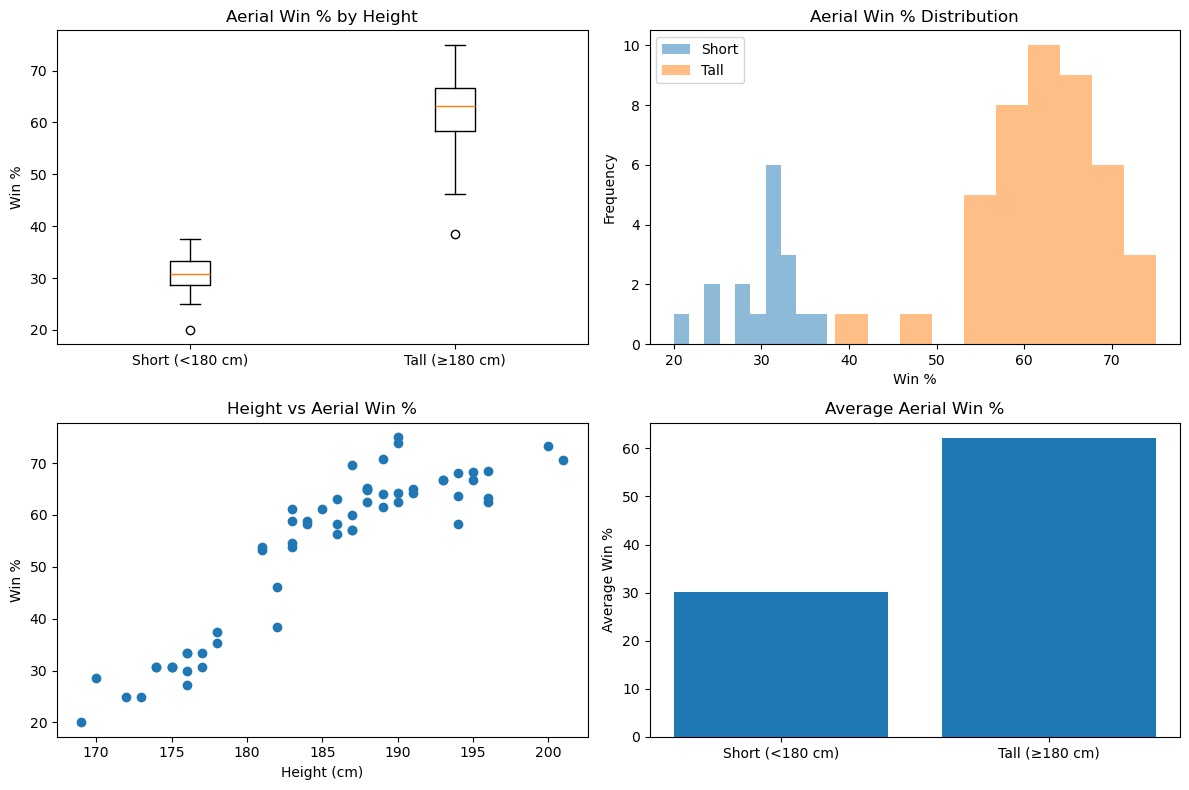

In [67]:
# ───  Visualisations ────────────────────────────────────────────────────────



groups = ['Short (<180 cm)', 'Tall (≥180 cm)']

short = df_sample[df_sample['Height_Group'] == 'Short (<180 cm)']
tall = df_sample[df_sample['Height_Group'] == 'Tall (≥180 cm)']

fig, ax = plt.subplots(2, 2, figsize=(12, 8))


ax[0, 0].boxplot([
    short['Aerial_Win_Pct'],
    tall['Aerial_Win_Pct']
])

ax[0, 0].set_xticklabels(groups)
ax[0, 0].set_title('Aerial Win % by Height')
ax[0, 0].set_ylabel('Win %')


ax[0, 1].hist(short['Aerial_Win_Pct'], bins=10, alpha=0.5, label='Short')
ax[0, 1].hist(tall['Aerial_Win_Pct'], bins=10, alpha=0.5, label='Tall')

ax[0, 1].set_title('Aerial Win % Distribution')
ax[0, 1].set_xlabel('Win %')
ax[0, 1].set_ylabel('Frequency')
ax[0, 1].legend()


ax[1, 0].scatter(
    df_sample['Height_cm'],
    df_sample['Aerial_Win_Pct']
)

ax[1, 0].set_title('Height vs Aerial Win %')
ax[1, 0].set_xlabel('Height (cm)')
ax[1, 0].set_ylabel('Win %')



means = [
    short['Aerial_Win_Pct'].mean(),
    tall['Aerial_Win_Pct'].mean()
]

ax[1, 1].bar(groups, means)

ax[1, 1].set_title('Average Aerial Win %')
ax[1, 1].set_ylabel('Average Win %')


plt.tight_layout()
plt.show()



In [53]:
# ───  Confidence Interval — Taller Group ────────────────────────────────────

tall_group = df_sample[df_sample['Height_Group'] == 'Tall (≥180 cm)']['Aerial_Win_Pct']

n_tall    = len(tall_group)
mean_tall = tall_group.mean()
std_tall  = tall_group.std(ddof=1)    # sample std dev
se_tall   = std_tall / np.sqrt(n_tall)  # standard error
alpha     = 0.05
t_crit    = stats.t.ppf(1 - alpha/2, df=n_tall - 1)  # two-tailed critical value
margin    = t_crit * se_tall
ci_lower  = mean_tall - margin
ci_upper  = mean_tall + margin

print('='*60)
print('95% Confidence Interval — Taller Group (Height ≥ 180 cm)')
print('='*60)
print(f'  Sample size (n)         : {n_tall}')
print(f'  Sample mean (x̄)         : {mean_tall:.4f} %')
print(f'  Sample Std Dev (s)      : {std_tall:.4f} %')
print(f'  Standard Error (SE)     : {se_tall:.4f} %')
print(f'  Degrees of freedom      : {n_tall - 1}')
print(f'  t-critical (α/2=0.025)  : {t_crit:.4f}')
print(f'  Margin of Error         : ±{margin:.4f} %')
print(f'  95% CI                  : ({ci_lower:.4f} %, {ci_upper:.4f} %)')
print()


95% Confidence Interval — Taller Group (Height ≥ 180 cm)
  Sample size (n)         : 43
  Sample mean (x̄)         : 62.2114 %
  Sample Std Dev (s)      : 7.0703 %
  Standard Error (SE)     : 1.0782 %
  Degrees of freedom      : 42
  t-critical (α/2=0.025)  : 2.0181
  Margin of Error         : ±2.1759 %
  95% CI                  : (60.0355 %, 64.3873 %)



In [93]:
# ───   CI for shorter group (for comparison reporting) ─────────

short_group = df_sample[df_sample['Height_Group'] == 'Short (<180 cm)']['Aerial_Win_Pct']

n_short    = len(short_group)
mean_short = short_group.mean()
std_short  = short_group.std(ddof=1)
se_short   = std_short / np.sqrt(n_short)
t_crit_s   = stats.t.ppf(1 - alpha/2, df=n_short - 1)
margin_s   = t_crit_s * se_short

print('='*60)
print('95% Confidence Interval — Shorter Group (Height < 180 cm)')
print('='*60)
print(f'  Sample size (n)  : {n_short}')
print(f'  Sample mean (x̄)  : {mean_short:.4f} %')
print(f'  Sample Std Dev   : {std_short:.4f} %')
print(f'  95% CI           : ({mean_short - margin_s:.4f} %, {mean_short + margin_s:.4f} %)')

95% Confidence Interval — Shorter Group (Height < 180 cm)
  Sample size (n)  : 17
  Sample mean (x̄)  : 30.1906 %
  Sample Std Dev   : 4.1828 %
  95% CI           : (28.0400 %, 32.3412 %)


In [95]:
# ───  Assumption Checks ────────────────────────────────────────────────────

print('=== Assumption 1: Normality — Shapiro-Wilk Test ===')
for grp_name, grp_data in [('Short (<180 cm)', short_group), ('Tall (≥180 cm)', tall_group)]:
    stat, p = stats.shapiro(grp_data)
    result = 'NORMAL ✓' if p > 0.05 else 'NON-NORMAL ✗'
    print(f'  {grp_name:25s}: W={stat:.4f}, p={p:.4f}  → {result}')

print()
print('=== Assumption 2: Equality of Variances — Levene\'s Test ===')
lev_stat, lev_p = stats.levene(short_group, tall_group)
equal_var = lev_p > 0.05
print(f'  Levene statistic: {lev_stat:.4f}')
print(f'  p-value         : {lev_p:.4f}')
print(f'  Equal variances : {"YES ✓" if equal_var else "NO — Welch t-test will be used ✓"}')

=== Assumption 1: Normality — Shapiro-Wilk Test ===
  Short (<180 cm)          : W=0.9365, p=0.2787  → NORMAL ✓
  Tall (≥180 cm)           : W=0.9503, p=0.0611  → NORMAL ✓

=== Assumption 2: Equality of Variances — Levene's Test ===
  Levene statistic: 3.5007
  p-value         : 0.0664
  Equal variances : YES ✓


In [97]:
# ───  Two-Sample t-Test ────────────────────────────────────────────────────


t_stat, p_value = stats.ttest_ind(tall_group, short_group, equal_var=equal_var, alternative='greater')



t_stat_2t, p_value_2t = stats.ttest_ind(tall_group, short_group, equal_var=equal_var)


if not equal_var:
    s1, n1 = std_tall**2, n_tall
    s2, n2 = std_short**2, n_short
    df_welch = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))
else:
    df_welch = n_tall + n_short - 2


pooled_sd = np.sqrt(((n_tall - 1)*std_tall**2 + (n_short - 1)*std_short**2) / (n_tall + n_short - 2))
cohen_d = (mean_tall - mean_short) / pooled_sd

print('='*65)
print('TWO-SAMPLE t-TEST RESULTS')
print('='*65)
print(f'  H₀: μ_tall  =  μ_short  (no difference in aerial win %)')
print(f'  H₁: μ_tall  >  μ_short  (taller players win more aerials)')
print(f'  Significance level α = 0.05')
print()
print(f'  Group          n    Mean (%)   Std Dev')
print(f'  Tall (≥180 cm) {n_tall:3d}  {mean_tall:7.3f}    {std_tall:.3f}')
print(f'  Short (<180 cm){n_short:3d}  {mean_short:7.3f}    {std_short:.3f}')
print(f'  Mean difference: {mean_tall - mean_short:.3f} %')
print()
test_type = "Welch's" if not equal_var else "Student's"
print(f'  Test type       : {test_type} two-sample t-test')
print(f'  t-statistic     : {t_stat:.4f}')
print(f'  Degrees of freedom: {df_welch:.2f}')
print(f'  p-value (one-tail): {p_value:.4f}')
print(f'  p-value (two-tail): {p_value_2t:.4f}')
print(f'  Cohen\'s d (effect size): {cohen_d:.4f}')
print()

if p_value_2t < 0.05:
    print('  DECISION: REJECT H₀')
    print(f'  The difference in mean aerial-duel win % between tall and short')
    print(f'  WC2026 outfield players IS statistically significant (p = {p_value_2t:.4f} < 0.05).')
    print(f'  Taller players (≥180 cm) win aerial duels at a significantly higher rate.')
else:
    print('  DECISION: FAIL TO REJECT H₀')
    print(f'  The difference is NOT statistically significant (p = {p_value_2t:.4f} ≥ 0.05).')


if abs(cohen_d) < 0.2:
    effect_label = 'negligible'
elif abs(cohen_d) < 0.5:
    effect_label = 'small'
elif abs(cohen_d) < 0.8:
    effect_label = 'medium'
else:
    effect_label = 'large'
print(f'\n  Effect size: Cohen\'s d = {cohen_d:.3f} → {effect_label} effect')

TWO-SAMPLE t-TEST RESULTS
  H₀: μ_tall  =  μ_short  (no difference in aerial win %)
  H₁: μ_tall  >  μ_short  (taller players win more aerials)
  Significance level α = 0.05

  Group          n    Mean (%)   Std Dev
  Tall (≥180 cm)  43   62.211    7.070
  Short (<180 cm) 17   30.191    4.183
  Mean difference: 32.021 %

  Test type       : Student's two-sample t-test
  t-statistic     : 17.4497
  Degrees of freedom: 58.00
  p-value (one-tail): 0.0000
  p-value (two-tail): 0.0000
  Cohen's d (effect size): 4.9992

  DECISION: REJECT H₀
  The difference in mean aerial-duel win % between tall and short
  WC2026 outfield players IS statistically significant (p = 0.0000 < 0.05).
  Taller players (≥180 cm) win aerial duels at a significantly higher rate.

  Effect size: Cohen's d = 4.999 → large effect


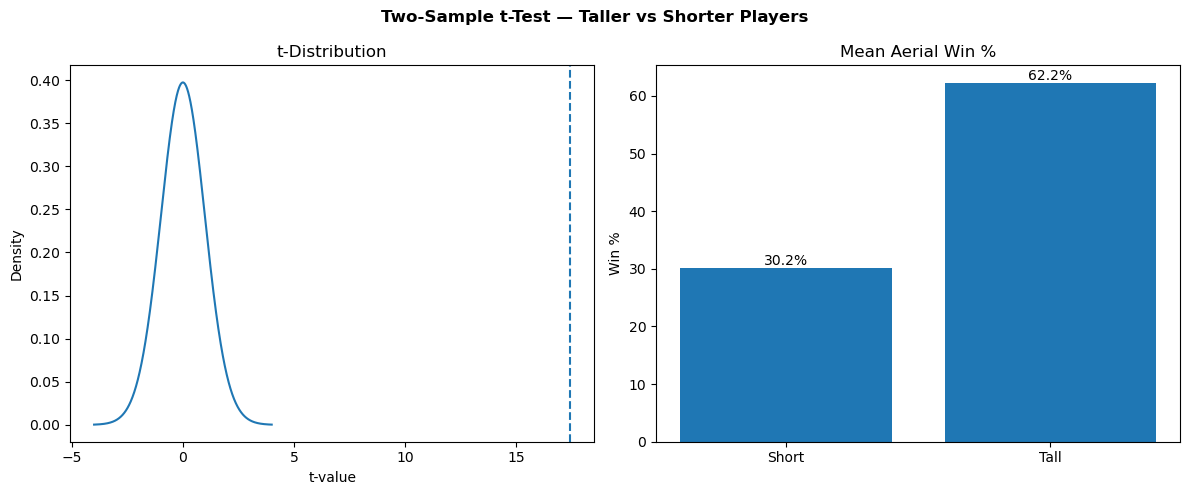

In [101]:

# ─── Visualise t-test ─────────────────────────────────────────

df_t = len(tall_group) + len(short_group) - 2


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

plt.suptitle(
    'Two-Sample t-Test — Taller vs Shorter Players',
    fontweight='bold'
)

x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=df_t)

ax[0].plot(x, y)
ax[0].axvline(t_stat_2t, linestyle='--')

ax[0].set_title('t-Distribution')
ax[0].set_xlabel('t-value')
ax[0].set_ylabel('Density')


groups = ['Short', 'Tall']
means = [mean_short, mean_tall]

ax[1].bar(groups, means)

ax[1].set_title('Mean Aerial Win %')
ax[1].set_ylabel('Win %')

for i, mean in enumerate(means):
    ax[1].text(i, mean, f'{mean:.1f}%', ha='center', va='bottom')


plt.tight_layout()
plt.show()

